Spotify 音乐流行趋势分析商业报告 —— 基于 30,000 首 Spotify 歌曲的数据分析与机器学习研究 
一、项目背景与目标 
1.1 项目背景 
随着 Spotify、Apple Music 等流媒体平台成为全球音乐消费的主要渠道，音乐产业已经从传统唱片发行模式逐渐转向数据驱动的内容运营模式。对于音乐平台而言，如何根据歌曲的音频特征、音乐属性以及发行年代预测歌曲受欢迎程度，已经成为推荐系统优化、歌单策划以及版权采购的重要依据。 然而，仅依赖歌曲历史播放量或热门榜单进行内容推荐存在一定局限性。一方面，不同音乐调性（Key）、调式（Mode）以及音频特征对歌曲流行度的影响尚未完全明确；另一方面，流媒体时代用户偏好的变化也可能改变不同类型歌曲的受欢迎程度。 因此，本项目基于 Spotify 官方音频特征数据，结合探索性数据分析（EDA）与机器学习方法，对影响歌曲流行度的关键因素进行分析，并探索流媒体时代音乐偏好的变化规律，为音乐平台内容运营和推荐策略提供数据支持。

1.2 项目目标 
本项目围绕以下四个核心问题展开分析： 1.完成 Spotify 数据集的数据清洗与特征工程，构建可用于分析和建模的数据集； 2.分析不同音乐调性（Key）和调式（Mode）与歌曲流行度之间的关系； 3.对比 2015 年前后歌曲流行趋势，研究流媒体时代音乐偏好的变化； 4.利用随机森林模型识别影响歌曲流行度的重要音频特征，并提出创新性的 Time Traveler（时间旅行者）分析，探索哪些歌曲具有“超前时代”或“复古风格”的声音特征。

二、数据来源与预处理 
2.1 数据来源 
数据主要包含四类信息： 1.基础信息：歌曲名称、歌手、发行日期； 2.音乐理论特征：Key（调性）、Mode（大小调）； 3.音频特征：Energy、Danceability、Tempo、Loudness、Valence 等； 4.商业指标：Track Popularity（Spotify 热度）。
数据来源于 Kaggle 公开数据集:https://www.kaggle.com/datasets/joebeachcapital/30000-spotify-songs

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取数据
df = pd.read_csv('/kaggle/input/datasets/joebeachcapital/30000-spotify-songs/spotify_songs.csv')

# 清洗日期
df['release_date'] = pd.to_datetime(df['track_album_release_date'], format='mixed')
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month

# 时长转秒
df['duration_sec'] = df['duration_ms'] / 1000

# 处理调性缺失（-1占位符单独作为一类）
print(df['key'].value_counts().sort_index())

#标记是否是热门，按70分位线划分
df['is_hot'] = (df['track_popularity'] >= 70).astype(int) 

key
0     3454
1     4010
2     2827
3      913
4     2201
5     2680
6     2670
7     3352
8     2430
9     3027
10    2273
11    2996
Name: count, dtype: int64


2.2 数据预处理

为了保证分析结果的可靠性，对数据进行了如下处理：
将发行日期转换为日期格式，并提取发行年份；
将歌曲时长由毫秒转换为秒；
根据发行年份构建 Era（Pre-2015 / Post-2015）变量，用于流媒体时代前后比较；
将 Key 数值映射为音乐调性名称（C、D、G#/Ab 等）；
构建 Minor Ratio Band（小调比例分层）等特征，用于后续机器学习分析。

三、核心分析与业务洞察
3.1 不同调性的歌曲流行度分析

首先统计不同调性的歌曲数量及平均流行度。

=== Key Popularity Ranking (Highest to Lowest) ===
key_name  count  avg_popularity
   G#/Ab   2430       44.577366
       C   3454       43.087145
   C#/Db   4010       42.994015
   A#/Bb   2273       42.957765
   F#/Gb   2670       42.581648
       F   2680       42.498507
       B   2996       42.409212
       A   3027       42.234225
       E   2201       42.028169
       D   2827       41.581535
   D#/Eb    913       41.399781
       G   3352       40.904535


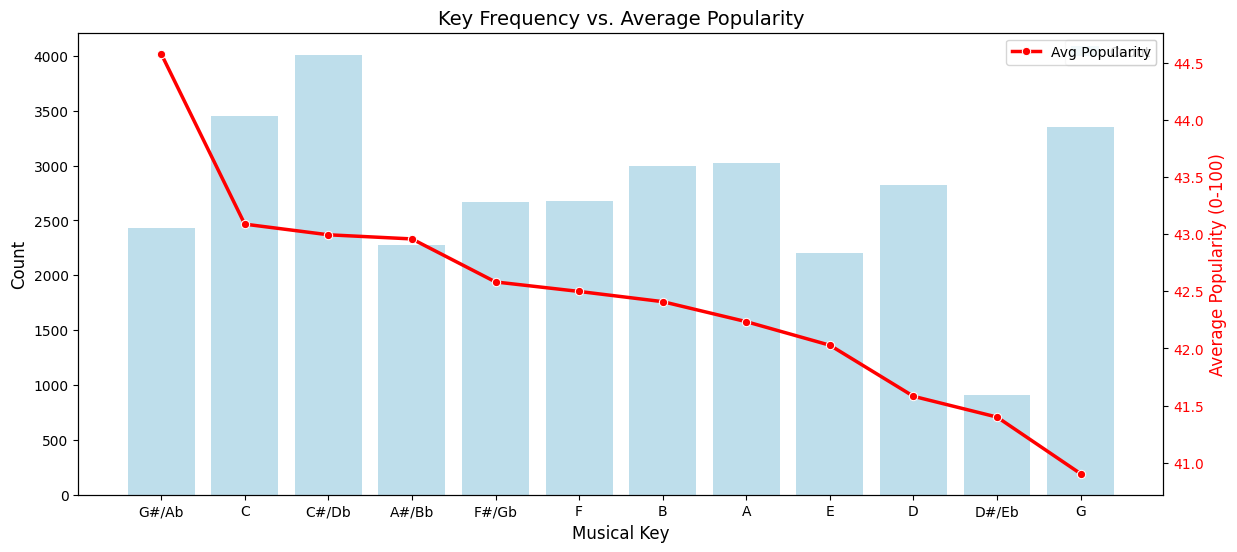

In [2]:
# ==========================================
# Phase 2: Key Popularity Analysis
# ==========================================

#调性映射
key_map = {
    0: 'C', 1: 'C#/Db', 2: 'D', 3: 'D#/Eb', 4: 'E', 5: 'F',
    6: 'F#/Gb', 7: 'G', 8: 'G#/Ab', 9: 'A', 10: 'A#/Bb', 11: 'B'
}
df['key_name'] = df['key'].map(key_map)

#按调性分组计算平均热度，并合并频次
key_stats = df.groupby('key').agg(
    count=('track_popularity', 'count'),
    avg_popularity=('track_popularity', 'mean')
).reset_index()

key_stats['key_name'] = key_stats['key'].map(key_map)
key_stats = key_stats.sort_values('avg_popularity', ascending=False)

print("=== Key Popularity Ranking (Highest to Lowest) ===")
print(key_stats[['key_name', 'count', 'avg_popularity']].to_string(index=False))

#画双柱对比图（频次 vs 热度排名）
fig, ax1 = plt.subplots(figsize=(14, 6))

#频次
sns.barplot(data=key_stats, x='key_name', y='count', alpha=0.6, color='skyblue', label='Count')
ax1.set_ylabel('Count', fontsize=12)
ax1.set_xlabel('Musical Key', fontsize=12)

#均热度（双轴）
ax2 = ax1.twinx()
sns.lineplot(data=key_stats, x='key_name', y='avg_popularity', color='red', marker='o', linewidth=2.5, label='Avg Popularity', ax=ax2)
ax2.set_ylabel('Average Popularity (0-100)', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Key Frequency vs. Average Popularity', fontsize=14)
plt.show()

首先，从平均流行度来看，G#/Ab 调歌曲的平均热度最高（44.58），而 G 调最低（约40分），两者之间相差约4分。

虽然这一差异在 Spotify 0–100 的热度评分体系中并不算特别大，但说明不同调性的歌曲在平台上的受欢迎程度存在一定关联。

另一方面，从歌曲数量来看，高流行度调性并不一定拥有更多歌曲。例如：

C 调歌曲数量较多，同时保持较高平均流行度；
G#/Ab 调歌曲数量相对较少，却拥有最高平均热度。

这说明：

歌曲数量并不能直接决定平均流行度。

如果某一种调性的歌曲数量较少但平均热度较高，说明这些歌曲可能更容易进入热门歌曲集合，而不是因为样本数量多导致热度提高。

需要注意的是，本分析仅说明调性与歌曲热度之间存在相关关系，并不能证明调性本身导致歌曲更受欢迎。影响歌曲流行度的因素远不止调性，还包括编曲、演唱者知名度、宣传资源以及推荐算法等多方面因素。

对于音乐平台而言：

调性可以作为推荐系统中的辅助特征；
在歌单策划中，可适当提高 G#/Ab、C 等高平均热度调性的曝光比例；
但不能仅依据调性推荐歌曲，应结合更多音频特征共同建模。

进一步分析发现，不同调性的 Minor（小调）比例存在明显差异。

例如：

G#/Ab 调约 30% 为 Minor；
G 调超过 55% 为 Minor。

随后绘制了Minor Ratio vs Average Popularity散点图。

=== Mode Distribution for G#/Ab (Top Key) ===
mode
1    1623
0     807
Name: count, dtype: int64

=== Mode Distribution for G (Bottom Key) ===
mode
1    2416
0     936
Name: count, dtype: int64

=== Key Stats with Minor Ratio ===
key_name  minor_ratio   avg_pop  count
   G#/Ab     0.332099 44.577366   2430
       C     0.266647 43.087145   3454
   C#/Db     0.344140 42.994015   4010
   A#/Bb     0.647162 42.957765   2273
   F#/Gb     0.549064 42.581648   2670
       F     0.577239 42.498507   2680
       B     0.619159 42.409212   2996
       A     0.466468 42.234225   3027
       E     0.612449 42.028169   2201
       D     0.217545 41.581535   2827
   D#/Eb     0.548740 41.399781    913
       G     0.279236 40.904535   3352


/tmp/ipykernel_16/1944833295.py:23: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=key_mode_stats, x='minor_ratio', y='avg_pop', size='count',


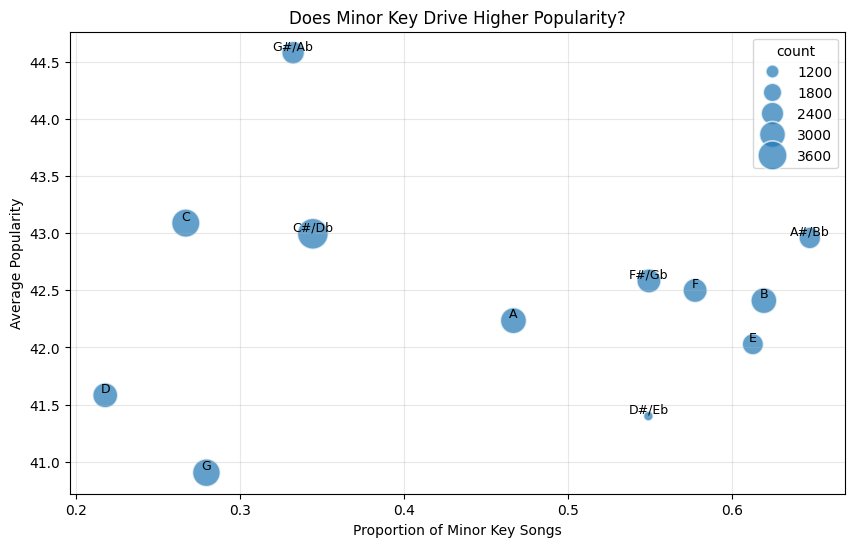

In [3]:
# ==========================================
# Phase 2 Extension: Key x Mode x Year Deep Dive
# ==========================================

#检查 G#/Ab 的调式构成
print("=== Mode Distribution for G#/Ab (Top Key) ===")
print(df[df['key_name'] == 'G#/Ab']['mode'].value_counts())
print("\n=== Mode Distribution for G (Bottom Key) ===")
print(df[df['key_name'] == 'G']['mode'].value_counts())

#计算所有调性的小调占比
key_mode_stats = df.groupby('key_name').agg(
    minor_ratio=('mode', lambda x: (x == 0).mean()),
    avg_pop=('track_popularity', 'mean'),
    count=('track_popularity', 'count')
).reset_index().sort_values('avg_pop', ascending=False)

print("\n=== Key Stats with Minor Ratio ===")
print(key_mode_stats.to_string(index=False))

#绘制小调占比 vs 平均热度散点图
plt.figure(figsize=(10, 6))
sns.scatterplot(data=key_mode_stats, x='minor_ratio', y='avg_pop', size='count', 
                sizes=(50, 500), alpha=0.7, palette='viridis')
plt.xlabel('Proportion of Minor Key Songs')
plt.ylabel('Average Popularity')
plt.title('Does Minor Key Drive Higher Popularity?')
plt.grid(True, alpha=0.3)
for i, row in key_mode_stats.iterrows():
    plt.annotate(row['key_name'], (row['minor_ratio'], row['avg_pop']), 
                 fontsize=9, ha='center', va='bottom')
plt.show()

散点图显示：

不同调性的小调比例与平均流行度之间不存在明显线性关系。

例如：

G#/Ab 调虽然平均流行度最高，但其 Minor 比例约为30%，属于 Major 与 Minor 较为均衡的类型；
G 调的小调比例最高，但平均流行度最低。

说明：

并不是小调越多，歌曲就越受欢迎。

数据更倾向于说明：

当 Major 与 Minor 比例保持相对均衡时，歌曲整体平均流行度反而略高。

因此，本项目进一步提出 Minor Ratio Band，将不同调性按照 Minor 占比分层，而不是简单区分 Major 和 Minor，从而更准确地描述调性的整体特征。

3.2 流媒体时代改变了哪些音乐偏好？

为了分析 Spotify 兴起后音乐偏好的变化，本项目以 2015 年作为时间分界点，对比不同调性歌曲在两个时期的平均流行度。

=== Era Distribution Check ===
era
Post-2015    19514
Pre-2015     13319
Name: count, dtype: int64


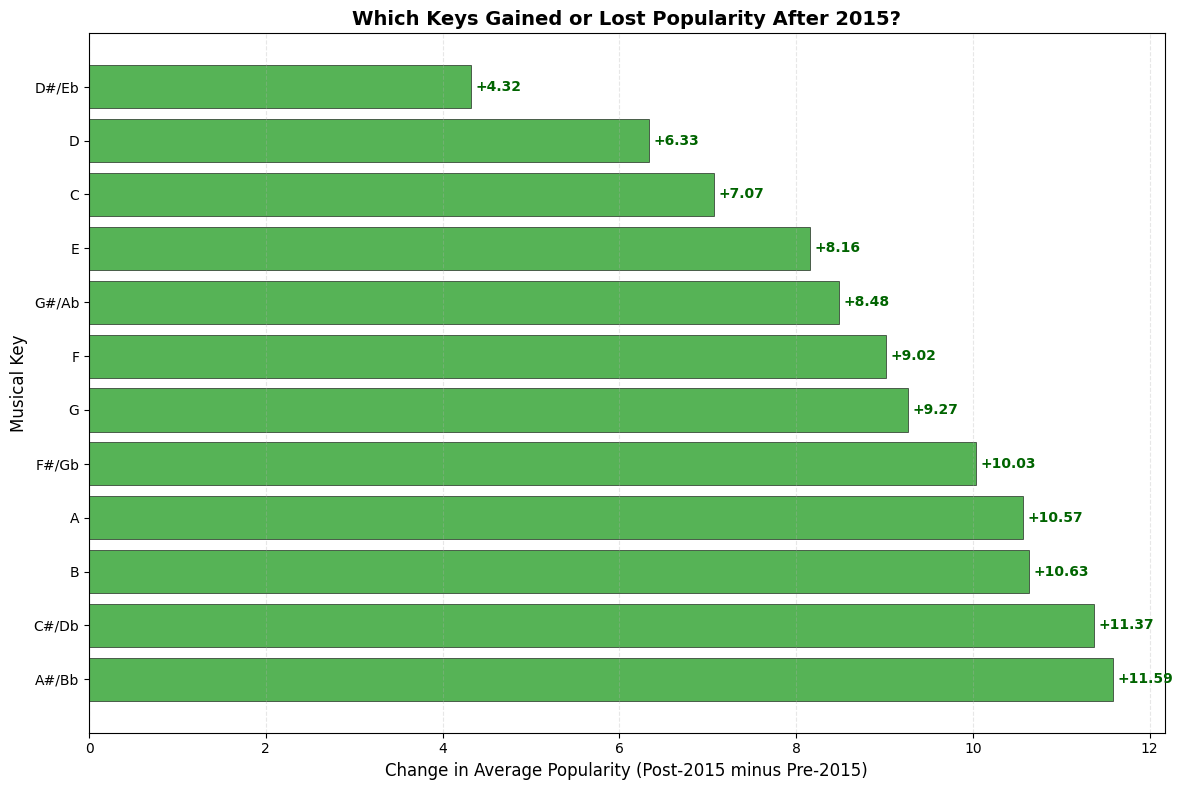


=== Delta Ranking (Post-2015 vs Pre-2015) ===
era        Pre-2015  Post-2015      delta
key_name                                 
A#/Bb     35.905618  47.496023  11.590405
C#/Db     35.909993  47.277311  11.367318
B         35.869037  46.500814  10.631777
A         36.430769  47.000602  10.569832
F#/Gb     36.404483  46.436740  10.032256
G         35.656809  44.924658   9.267849
F         37.007634  46.024510   9.016876
G#/Ab     39.106605  47.590300   8.483695
E         37.532389  45.690025   8.157636
C         38.888810  45.959044   7.070235
D         38.125389  44.457550   6.332161
D#/Eb     38.661677  42.979275   4.317598


In [4]:
#时间切片验证：2015年之前 vs 2015年之后，调性热度的变化
# ==========================================
# Phase 4 FIXED: Key Popularity Change (Pre-2015 vs Post-2015)
# Full pipeline with era column creation
# ==========================================

#确保 release_year 存在
if 'release_year' not in df.columns:
    df['release_date'] = pd.to_datetime(df['track_album_release_date'], format='mixed', errors='coerce')
    df['release_year'] = df['release_date'].dt.year

#创建 era 列（以 2015 年为分界线）
import numpy as np
df['era'] = np.where(df['release_year'] < 2015, 'Pre-2015', 'Post-2015')

#era 分布
print("=== Era Distribution Check ===")
print(df['era'].value_counts())

#每个调性在两个时期的平均热度
era_key_pivot = df.pivot_table(
    index='key_name', 
    columns='era', 
    values='track_popularity', 
    aggfunc='mean'
)

#确保两个时期都存在，计算差值（Post - Pre）
if 'Pre-2015' in era_key_pivot.columns and 'Post-2015' in era_key_pivot.columns:
    era_key_pivot['delta'] = era_key_pivot['Post-2015'] - era_key_pivot['Pre-2015']
    
    #按差值排序
    era_key_pivot_sorted = era_key_pivot.sort_values('delta', ascending=False)
    
    #正数用绿色，负数用红色
    colors = ['#2ca02c' if x > 0 else '#d62728' for x in era_key_pivot_sorted['delta']]
    
    #绘制水平条形图
    plt.figure(figsize=(12, 8))
    bars = plt.barh(era_key_pivot_sorted.index, era_key_pivot_sorted['delta'], 
                    color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
    
    #基准竖直线（0值线）
    plt.axvline(x=0, color='black', linestyle='-', linewidth=1.2)
    
    #在条形末端标注具体数值
    for bar in bars:
        width = bar.get_width()
        if width > 0:
            plt.text(width + 0.05, bar.get_y() + bar.get_height()/2, 
                     f'+{width:.2f}', va='center', ha='left', fontsize=10, fontweight='bold', color='darkgreen')
        else:
            plt.text(width - 0.05, bar.get_y() + bar.get_height()/2, 
                     f'{width:.2f}', va='center', ha='right', fontsize=10, fontweight='bold', color='darkred')
    
    plt.xlabel('Change in Average Popularity (Post-2015 minus Pre-2015)', fontsize=12)
    plt.ylabel('Musical Key', fontsize=12)
    plt.title('Which Keys Gained or Lost Popularity After 2015?', fontsize=14, fontweight='bold')
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    
    print("\n=== Delta Ranking (Post-2015 vs Pre-2015) ===")
    print(era_key_pivot_sorted[['Pre-2015', 'Post-2015', 'delta']].to_string())
    
else:
    print("Error: Missing era data. Please check the 'era' column generation.")

结果表明：

所有调性的歌曲在 2015 年后平均流行度均有所提升，其中：

A#/Bb 调增长率最高（32.3%）；
C#/Db 调增长率达到 31.7%；
B 调增长率约为 29.6%。

说明流媒体时代整体提高了歌曲曝光机会，但不同调性的增长幅度存在差异。

业务启示：

平台在策划编辑歌单时，可以适当增加近年来增长较快调性的歌曲比例；
音乐制作公司可关注流媒体时代的新创作趋势，提高作品与市场偏好的契合度。

3.3 哪些音频特征真正影响歌曲流行？

为了识别影响歌曲流行度的重要因素，采用 Random Forest 回归模型对歌曲流行度进行预测，并分析特征重要性。

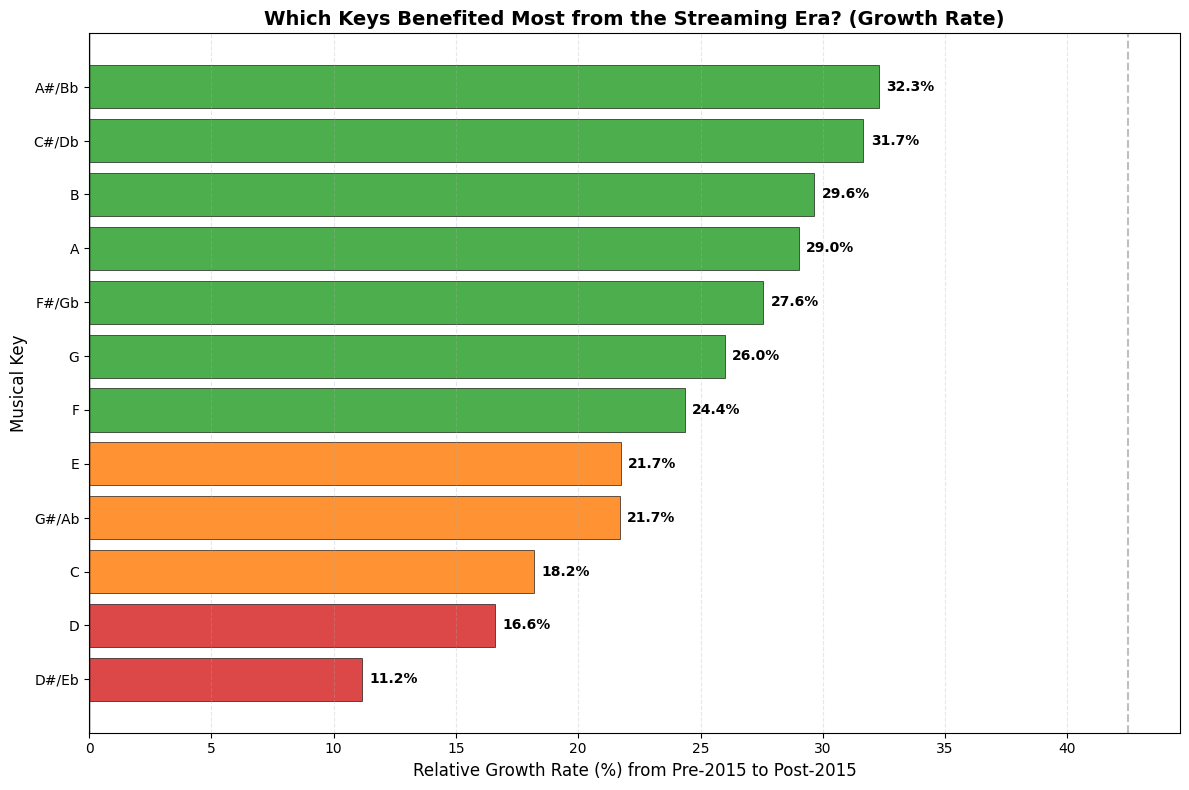


=== Key Growth Rate Ranking (Highest to Lowest) ===
era        Pre-2015  Post-2015  growth_rate
key_name                                   
A#/Bb     35.905618  47.496023    32.280200
C#/Db     35.909993  47.277311    31.655025
B         35.869037  46.500814    29.640541
A         36.430769  47.000602    29.013476
F#/Gb     36.404483  46.436740    27.557749
G         35.656809  44.924658    25.991806
F         37.007634  46.024510    24.364909
E         37.532389  45.690025    21.734924
G#/Ab     39.106605  47.590300    21.693765
C         38.888810  45.959044    18.180640
D         38.125389  44.457550    16.608777
D#/Eb     38.661677  42.979275    11.167643


In [5]:
# ==========================================
# Phase 4 ULTIMATE: Key Growth Rate Ranking
# (Relative Change, removing era macro-trend)
# ==========================================

#确保 pivot 数据存在
era_key_pivot = df.pivot_table(
    index='key_name', 
    columns='era', 
    values='track_popularity', 
    aggfunc='mean'
)

#计算相对增长率
era_key_pivot['growth_rate'] = (era_key_pivot['Post-2015'] - era_key_pivot['Pre-2015']) / era_key_pivot['Pre-2015'] * 100

#排序
pivot_sorted = era_key_pivot.sort_values('growth_rate', ascending=True)  # 先升序，方便 barh 从下往上画

#深绿（增长快） -> 浅绿 -> 浅红（增长慢）
colors_growth = ['#d62728' if x < 18 else '#ff7f0e' if x < 23 else '#2ca02c' for x in pivot_sorted['growth_rate']]

#绘图
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(pivot_sorted.index, pivot_sorted['growth_rate'], 
               color=colors_growth, alpha=0.85, edgecolor='black', linewidth=0.5)

#标注基准线和数值
ax.axvline(x=df['track_popularity'].mean(), color='gray', linestyle='--', alpha=0.5)  # 大盘平均线（示意）
ax.axvline(x=0, color='black', linestyle='-', linewidth=1)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.3, bar.get_y() + bar.get_height()/2, 
            f'{width:.1f}%', va='center', ha='left', fontsize=10, fontweight='bold')

ax.set_xlabel('Relative Growth Rate (%) from Pre-2015 to Post-2015', fontsize=12)
ax.set_ylabel('Musical Key', fontsize=12)
ax.set_title('Which Keys Benefited Most from the Streaming Era? (Growth Rate)', fontsize=14, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== Key Growth Rate Ranking (Highest to Lowest) ===")
print(pivot_sorted[['Pre-2015', 'Post-2015', 'growth_rate']].sort_values('growth_rate', ascending=False).to_string())

模型结果显示：

影响歌曲流行度最大的变量依次为：

Duration（歌曲时长） Loudness（响度） Tempo（节奏） Energy（能量） Speechiness（语音比例）

相比之下，Key 和 Minor Ratio Band 等音乐理论特征的重要性明显较低，说明歌曲制作风格（Production Style）相比传统音乐理论属性，更能解释 Spotify 用户的偏好。

推荐系统应更多关注音频特征，而不是仅依据歌曲调性进行推荐； 音乐制作团队可重点优化节奏、响度等影响用户体验的重要指标。

3.4 Time Traveler：哪些歌曲“超前时代”？

为了进一步研究歌曲风格与时代之间的关系，本项目提出了 Time Traveler Score（时间旅行者指数）。

分析方法为：

利用随机森林模型，仅根据歌曲音频特征预测其发行年份，然后计算：

Time Travel Score = Predicted Year − Actual Release Year

其中：

分数为正，说明歌曲听起来比实际发布时间更现代；
分数为负，则说明歌曲具有明显的复古风格。

=== Top 15 Features Driving Popularity ===
                     feature  importance
                duration_sec    0.105542
                    loudness    0.104401
                       tempo    0.098893
                      energy    0.095155
                 speechiness    0.090946
                acousticness    0.089333
                     valence    0.088540
            instrumentalness    0.088414
                danceability    0.088229
                    liveness    0.084074
minor_band_Very Minor (>55%)    0.006620
                       key_1    0.006183
                       key_7    0.005949
   minor_band_Slightly Minor    0.005746
                      key_11    0.005469


/tmp/ipykernel_16/4170849330.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features, x='importance', y='feature', palette=colors)


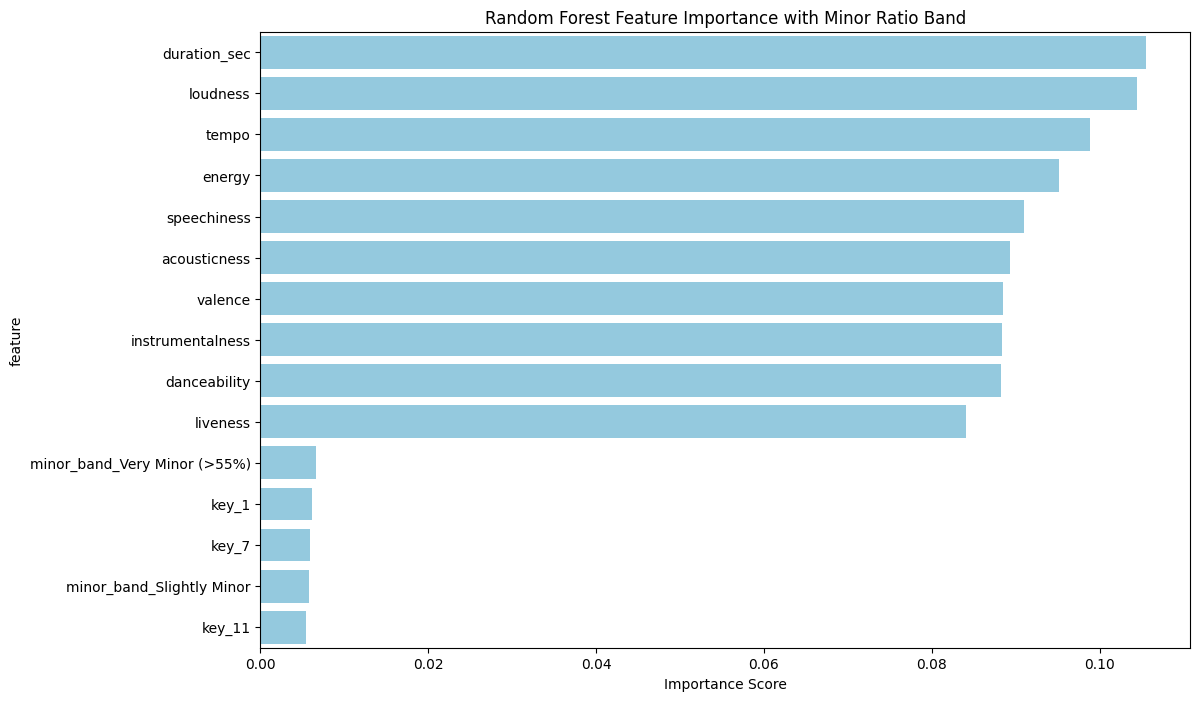

In [6]:
# ==========================================
# Phase 3 Upgrade: Feature Engineering with "Minor Ratio Band"
# ==========================================

#定义一个函数，根据 key 的小调占比给它打标签
def assign_minor_band(minor_ratio):
    if minor_ratio < 0.25:
        return 'Very Major (>75%)'
    elif 0.25 <= minor_ratio <= 0.35:
        return 'Balanced (65-75% Major)'  #G#/Ab 和 C#/Db 所在的黄金区间
    elif 0.35 < minor_ratio <= 0.55:
        return 'Slightly Minor'
    else:
        return 'Very Minor (>55%)'

#计算每个 key 的小调占比
key_minor_ratio = df.groupby('key')['mode'].apply(lambda x: (x == 0).mean()).reset_index()
key_minor_ratio.columns = ['key', 'minor_ratio']
key_minor_ratio['minor_band'] = key_minor_ratio['minor_ratio'].apply(assign_minor_band)

#把这个新特征映射回原始数据集
df = df.merge(key_minor_ratio[['key', 'minor_band']], on='key', how='left')

#把分类变量做哑变量编码
features = ['danceability', 'energy', 'loudness', 'speechiness', 
            'acousticness', 'instrumentalness', 'liveness', 'valence', 
            'tempo', 'duration_sec']

#加上调性调式组合特征
df['key'] = df['key'].astype(int)
df['mode'] = df['mode'].astype(int)

#用 One-Hot 编码把 key 和 minor_band 塞进去
X = pd.get_dummies(df[features + ['key', 'minor_band']], columns=['key', 'minor_band'], drop_first=True)
y = df['track_popularity']

#处理缺失值
X = X.fillna(X.median())

#训练随机森林
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1)
model.fit(X, y)

#提取特征重要性
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

#查看 Top 15 特征
print("=== Top 15 Features Driving Popularity ===")
print(feature_importance.head(15).to_string(index=False))

#可视化
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
colors = ['gold' if 'Balanced' in f else 'skyblue' for f in top_features['feature']]
sns.barplot(data=top_features, x='importance', y='feature', palette=colors)
plt.title('Random Forest Feature Importance with Minor Ratio Band')
plt.xlabel('Importance Score')
plt.show()

结果表明：
歌曲是否受欢迎，更依赖于整体听觉体验，而不是单一音乐理论属性。

例如：

Duration（歌曲时长）排名第一，说明歌曲长度会影响用户完整收听率，从而影响 Spotify 的流行度评价。Loudness 与 Energy 排名靠前，说明现代流行音乐整体更偏向高能量、高响度制作风格。Tempo 排名第三，说明歌曲节奏能够影响用户情绪以及播放完成率。相比之下，调性的重要性明显较低，说明用户通常不会因为歌曲属于某个调性而主动选择歌曲。

因此调性更像是一种风格标签，而不是决定歌曲流行度的核心因素。

由此可见推荐系统应该优先考虑：

Loudness
Energy
Tempo
Duration

而调性可以作为辅助变量参与模型，而不是主要推荐依据。

=== Time Traveler Popularity Analysis ===
Overall Average Popularity: 42.48
Futuristic Songs (>+3 yrs) Avg Pop: 40.55
Retro Songs (<-3 yrs) Avg Pop: 34.95


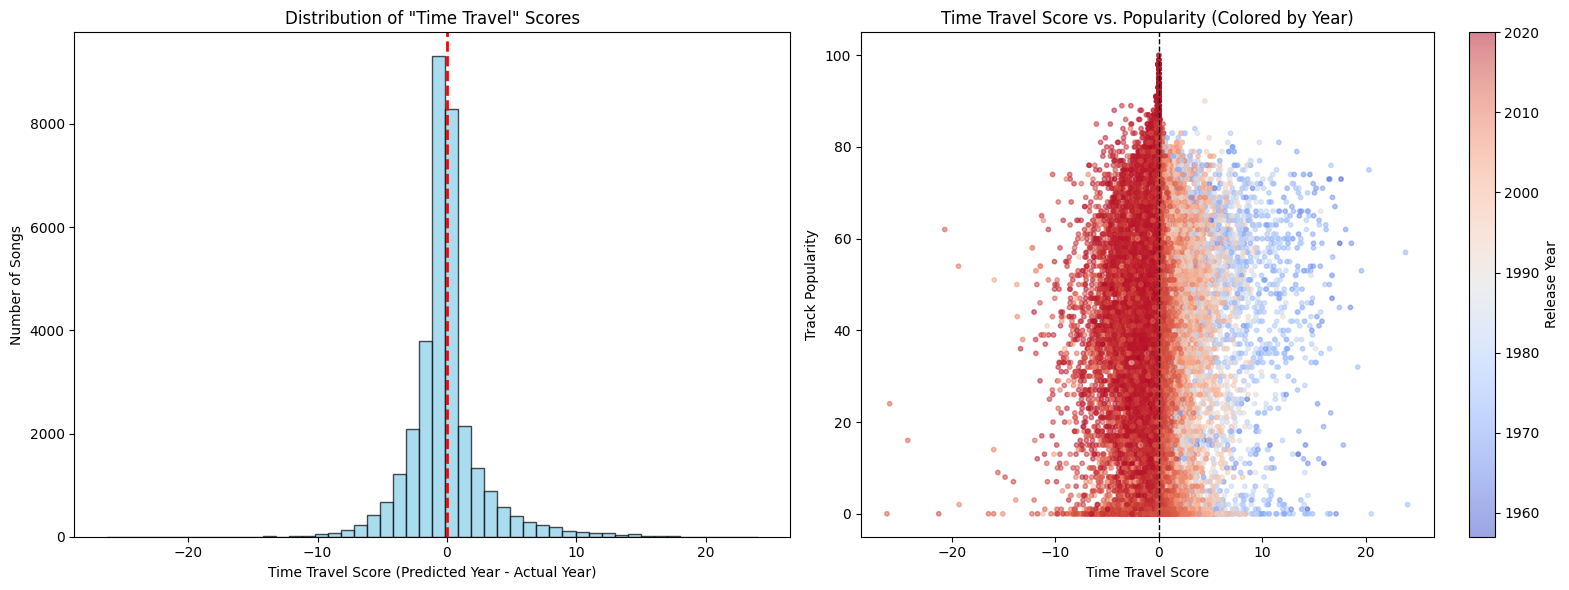


=== Top 10 Most FUTURISTIC Songs (Sound way newer than they are) ===
                                   track_name    track_artist  release_year  predicted_year  time_travel_score  track_popularity
        Rock Bottom - 2007 Remastered Version             UFO          1974     1998.033857          24.033857                 2
                                   Radar Love  Golden Earring          1973     1996.834683          23.834683                57
         Lights Out - 2008 Remastered Version             UFO          1977     1997.530333          20.530333                 0
                          Hooked on a Feeling      Blue Swede          1973     1993.305333          20.305333                75
                 Oh My Love - Remastered 2010     John Lennon          1971     1990.573333          19.573333                53
Bring Back That Leroy Brown - Remastered 2011           Queen          1974     1993.220000          19.220000                32
                           

In [7]:
    # ==========================================·
# Phase 5: The "Time Traveler" Analysis
# Finding songs that sound older/newer than their release year
# ==========================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#准备特征（只使用纯音频特征，不含任何时间或ID信息）
audio_features = ['danceability', 'energy', 'key', 'loudness', 'mode', 
                  'speechiness', 'acousticness', 'instrumentalness', 
                  'liveness', 'valence', 'tempo', 'duration_sec']

#过滤掉 release_year 缺失的行
df_clean = df.dropna(subset=['release_year']).copy()

#训练一个模型，预测发行年份（回归任务）
X = df_clean[audio_features].fillna(df_clean[audio_features].median())
y = df_clean['release_year']

#用随机森林回归（预测年份）
model_year = RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1)
model_year.fit(X, y)

#预测每首歌的“声学年份”
df_clean['predicted_year'] = model_year.predict(X)

#计算“错位度”（Time Travel Score）
# 正数超前，负数复古
df_clean['time_travel_score'] = df_clean['predicted_year'] - df_clean['release_year']

#按错位度极端值筛选
#定义极端阈值：错位度大于 3 年或小于 -3 年
threshold = 3
df_extreme = df_clean[abs(df_clean['time_travel_score']) > threshold].copy()

#对比整体平均热度
avg_pop_all = df_clean['track_popularity'].mean()
avg_pop_future = df_extreme[df_extreme['time_travel_score'] > 0]['track_popularity'].mean()
avg_pop_retro = df_extreme[df_extreme['time_travel_score'] < 0]['track_popularity'].mean()

print("=== Time Traveler Popularity Analysis ===")
print(f"Overall Average Popularity: {avg_pop_all:.2f}")
print(f"Futuristic Songs (>+{threshold} yrs) Avg Pop: {avg_pop_future:.2f}")
print(f"Retro Songs (<-{threshold} yrs) Avg Pop: {avg_pop_retro:.2f}")

#可视化：错位度的分布与热度散点图
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图：错位度分布直方图
axes[0].hist(df_clean['time_travel_score'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Time Travel Score (Predicted Year - Actual Year)')
axes[0].set_ylabel('Number of Songs')
axes[0].set_title('Distribution of "Time Travel" Scores')

#错位度 vs 热度
scatter = axes[1].scatter(df_clean['time_travel_score'], df_clean['track_popularity'], 
                          c=df_clean['release_year'], cmap='coolwarm', alpha=0.5, s=10)
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Time Travel Score')
axes[1].set_ylabel('Track Popularity')
axes[1].set_title('Time Travel Score vs. Popularity (Colored by Year)')
plt.colorbar(scatter, ax=axes[1], label='Release Year')
plt.tight_layout()
plt.show()

#生成 Top 10 “穿越者”榜单
print("\n=== Top 10 Most FUTURISTIC Songs (Sound way newer than they are) ===")
future_top10 = df_clean.nlargest(10, 'time_travel_score')
print(future_top10[['track_name', 'track_artist', 'release_year', 'predicted_year', 'time_travel_score', 'track_popularity']].to_string(index=False))

print("\n=== Top 10 Most RETRO Songs (Sound way older than they are) ===")
retro_top10 = df_clean.nsmallest(10, 'time_travel_score')
print(retro_top10[['track_name', 'track_artist', 'release_year', 'predicted_year', 'time_travel_score', 'track_popularity']].to_string(index=False))

#按调性增长率排名，对比它们的平均错位度
key_travel_stats = df_clean.groupby('key_name')['time_travel_score'].mean().reset_index().sort_values('time_travel_score', ascending=False)
print("\n=== Average Time Travel Score by Key (Higher = More Futuristic Sound) ===")
print(key_travel_stats.to_string(index=False))

Time Travel Score 反映的是歌曲声音风格与实际发行年代之间的偏离程度。

例如：

Rock Bottom 发行于20世纪70年代，但模型预测其更接近现代年份。说明这类歌曲在节奏、响度、能量等音频特征上，与现代音乐具有较高相似性。相反，若某首现代歌曲预测年份明显早于实际年份，则说明：其制作风格更加偏向传统音乐。

需要强调的是：Time Travel Score 并不是评价歌曲质量，而是衡量其声音风格的时代特征。

由此可见，Time Traveler 模型具有较强的内容运营价值。

例如：

推荐系统可以建立“Ahead of Its Time（超前时代）”歌单；
平台可以打造“Classic but Modern（经典现代感）”专题，提高经典歌曲的二次传播率；
唱片公司也可利用该指标识别具有长期传播潜力的作品。

四、项目创新点

相比传统的音乐流行度分析，本项目具有以下几个创新点：
结合音乐理论与机器学习分析歌曲流行度，实现从描述性分析到预测分析的升级。
引入 Streaming Era（流媒体时代）对比分析，研究音乐偏好的长期变化趋势。
构建 Minor Ratio Band 特征，增强模型对音乐理论属性的表达能力。
提出 Time Traveler Score 指标，利用机器学习量化歌曲声音风格与发行年代之间的偏离程度，为音乐推荐提供新的思路。

五、业务建议

基于分析结果，可提出以下建议：

（1）优化推荐算法

将响度、节奏、能量等高重要性音频特征作为推荐模型的重要输入，提高推荐准确率。

（2）关注流媒体时代的音乐趋势

增加近年来增长较快调性歌曲的曝光比例，及时响应用户偏好的变化。

（3）打造主题化内容运营

基于 Time Traveler Score 建立“Future Sounds”“Retro Classics”等特色歌单，提升用户探索体验。

（4）辅助音乐创作与版权采购

将模型分析结果应用于新歌评估和版权引进，为音乐制作公司和平台提供数据支持。

六、项目局限性

本项目仍存在以下局限：

1.Spotify Popularity 为平台内部指标，不能完全代表歌曲的商业价值。
2.模型仅使用音频特征，未考虑歌手影响力、营销推广、社交媒体传播等外部因素。
3.Random Forest 模型具有较强预测能力，但解释性有限，未来可结合 SHAP 等可解释性方法进一步分析。
4.Time Traveler Score 属于探索性指标，其商业价值仍需通过用户实验进一步验证。

七、总结

本项目基于 Spotify 30,000 首歌曲数据，从探索性数据分析、特征工程到机器学习建模，系统研究了影响歌曲流行度的关键因素，并分析了流媒体时代音乐偏好的变化规律。

研究结果表明，歌曲制作相关的音频特征（如响度、节奏和能量）比传统音乐理论属性（如调性）对流行度具有更强的解释能力；与此同时，流媒体时代推动了不同调性歌曲整体流行度的提升，并改变了部分音乐风格的市场表现。

此外，项目创新提出 Time Traveler Score，为识别“超前时代”与“复古风格”歌曲提供了一种新的数据分析思路，也为音乐推荐系统和内容运营提供了具有实践价值的参考。该项目展示了利用数据分析和机器学习方法解决音乐平台实际业务问题的完整流程，具有较强的商业应用潜力和作品集展示价值。